In [65]:
import numpy as np
import meshio

In [81]:

# Чтение VTK файла
mesh = meshio.read("/Users/alekseidushanin/Documents/GitHub/LFI_KT/miniproject/paraview_data/potential000000.vtu")

# Доступ к точкам и ячейкам
#print("Points:", mesh.points)
print(len(mesh.point_data['u']))

4225


[ 0.          0.          0.         ... 40.54356871 40.54235726
 40.54195207]
4225


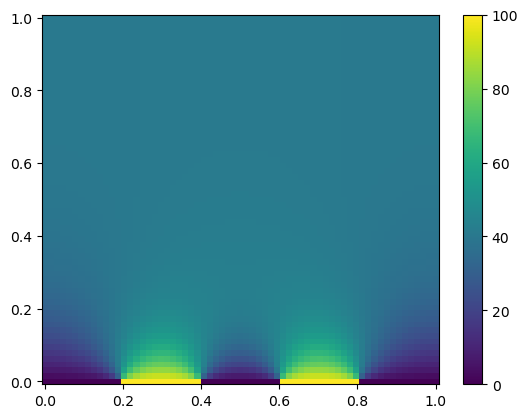

In [83]:
x_set = sorted(set(mesh.points[:, 0]))
y_set = sorted(set(mesh.points[:, 1]))
u = mesh.point_data['u']

print(u)

data = np.ndarray(shape = (len(x_set), len(y_set)))

for i in range(len(x_set)):
    for j in range(len(y_set)):
        data[i][j] = u[len(y_set) * i + j]

plt.pcolormesh(x_set, y_set, data)
print(len(x_set) * len(y_set))
plt.colorbar()

In [75]:
import os

with open('/Users/alekseidushanin/Documents/GitHub/LFI_KT/miniproject/dataset/sim_input.txt', 'w'):
    pass

f = open('/Users/alekseidushanin/Documents/GitHub/LFI_KT/miniproject/dataset/sim_input.txt', 'w')
f.write('/Users/alekseidushanin/Documents/GitHub/LFI_KT/miniproject/dataset/hello2.txt')
f.close()

os.system('/Users/alekseidushanin/Documents/GitHub/LFI_KT/miniproject/test')

0

In [77]:
class Ion_Trap_Simulation:
    def __init__(self, input_file_path, cpp_script_path, potential_vtu_output_path, ef_vtu_output_path):
        self.input_file_path = input_file_path
        self.cpp_script_path = cpp_script_path
        self.potential_vtu_output_path = potential_vtu_output_path
        self.ef_vtu_output_path = ef_vtu_output_path

    def perform_simulation(self):
        #Clear the input file
        with open(self.input_file_path, 'w'):
            pass
        
        #Fill the input file
        f = open(self.input_file_path, 'w')
        f.write(self.potential_vtu_output_path)
        f.close()
        
        #Run c++ sim script
        os.system(self.cpp_script_path)
        
        #Convert .vtu to .csv

sim = Ion_Trap_Simulation('/Users/alekseidushanin/Documents/GitHub/LFI_KT/miniproject/dataset/sim_input.txt',
                         '/Users/alekseidushanin/Documents/GitHub/LFI_KT/miniproject/test',
                         '/Users/alekseidushanin/Documents/GitHub/LFI_KT/miniproject/dataset/hello2.txt',
                         '/Users/alekseidushanin/Documents/GitHub/LFI_KT/miniproject/dataset/hello2.txt')

sim.perform_simulation()

In [119]:
def generate_Ex(potential, delta_x):
    Ex = np.ndarray(shape = (potential.shape[0] - 1, potential.shape[1] - 1))

    for i in range(potential.shape[0] - 1):
        for j in range(potential.shape[1] - 1):
            Ex[i][j] = (potential[i][j] - potential[i][j + 1]) / delta_x

    return Ex

def generate_Ey(potential, delta_y):
    Ey = np.ndarray(shape = (potential.shape[0] - 1, potential.shape[1] - 1))

    for i in range(potential.shape[0] - 1):
        for j in range(potential.shape[1] - 1):
            Ey[i][j] = (potential[i][j] - potential[i + 1][j]) / delta_y

    return Ey

def generate_pseudo_potential(Ex, Ey, Q, M, Freq):
    return (Ex ** 2 + Ey ** 2) * Q ** 2 / (4 * M * Freq ** 2)

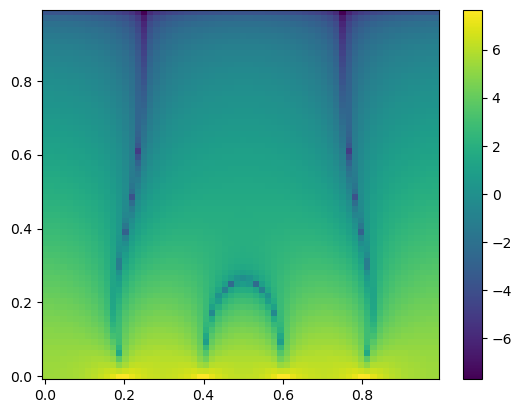

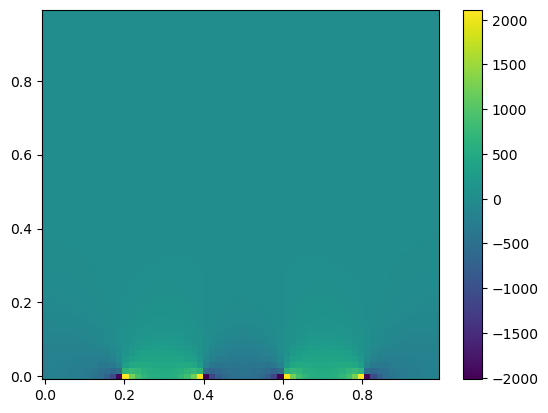

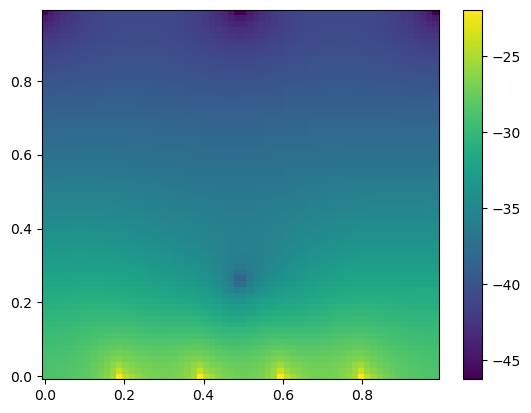

In [127]:
plt.pcolormesh(x_set[:-1], y_set[:-1], np.log(np.abs(generate_Ey(data, x_set[1] - x_set[0]))))
plt.colorbar()
plt.show()

plt.pcolormesh(x_set[:-1], y_set[:-1], generate_Ey(data, x_set[1] - x_set[0]))
plt.colorbar()
plt.show()

plt.pcolormesh(x_set[:-1], y_set[:-1], np.log(np.abs(generate_pseudo_potential(generate_Ex(data, x_set[1] - x_set[0]),
                                                                 generate_Ey(data, y_set[1] - y_set[0]),
                                                                1.6e-19, 1e-27, 1e3))))
plt.colorbar()

In [147]:
def convert_vtu_to_csv(potential_vtu_file_path,
                       potential_file_path, 
                       pp_file_path, 
                       Ex_file_path, 
                       Ey_file_path, 
                       Ez_file_path,
                       Q, M, Freq):
    
    mesh = meshio.read(potential_vtu_file_path)

    x_set = sorted(set(mesh.points[:, 0]))
    y_set = sorted(set(mesh.points[:, 1]))
    u = mesh.point_data['u']

    potential = np.ndarray(shape = (len(x_set), len(y_set)))
    for i in range(len(x_set)):
        for j in range(len(y_set)):
            potential[i][j] = u[len(y_set) * i + j]

    Ex = generate_Ex(potential, x_set[1] - x_set[0])
    Ey = generate_Ey(potential, y_set[1] - y_set[0])
    pp = generate_pseudo_potential(Ex, Ey, Q, M, Freq)

    np.savetxt(potential_file_path, potential, delimiter=',')
    np.savetxt(pp_file_path, pp, delimiter=',')
    np.savetxt(Ex_file_path, Ex, delimiter=',')
    np.savetxt(Ey_file_path, Ey, delimiter=',')
    np.savetxt(Ez_file_path, np.zeros(shape = Ex.shape), delimiter=',')

In [145]:
convert_vtu_to_csv("/Users/alekseidushanin/Documents/GitHub/LFI_KT/miniproject/paraview_data/potential000000.vtu",
                  "/Users/alekseidushanin/Documents/GitHub/LFI_KT/miniproject/dataset/potential.csv",
                  "/Users/alekseidushanin/Documents/GitHub/LFI_KT/miniproject/dataset/pp.csv",
                  "/Users/alekseidushanin/Documents/GitHub/LFI_KT/miniproject/dataset/Ex.csv",
                  "/Users/alekseidushanin/Documents/GitHub/LFI_KT/miniproject/dataset/Ey.csv",
                  "/Users/alekseidushanin/Documents/GitHub/LFI_KT/miniproject/dataset/Ez.csv",
                  1, 1, 1)